In [1]:
# importing the dependencies

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
import warnings
warnings.filterwarnings('ignore')

In [2]:
# loading the dataset

df= pd.read_csv('fraud.csv')

In [3]:
# first 5 rows of the dataset

df.head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0


In [4]:
# quick information about the dataset

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6362620 entries, 0 to 6362619
Data columns (total 11 columns):
 #   Column          Dtype  
---  ------          -----  
 0   step            int64  
 1   type            object 
 2   amount          float64
 3   nameOrig        object 
 4   oldbalanceOrg   float64
 5   newbalanceOrig  float64
 6   nameDest        object 
 7   oldbalanceDest  float64
 8   newbalanceDest  float64
 9   isFraud         int64  
 10  isFlaggedFraud  int64  
dtypes: float64(5), int64(3), object(3)
memory usage: 534.0+ MB


In [5]:
# all features of the dataset

df.columns

Index(['step', 'type', 'amount', 'nameOrig', 'oldbalanceOrg', 'newbalanceOrig',
       'nameDest', 'oldbalanceDest', 'newbalanceDest', 'isFraud',
       'isFlaggedFraud'],
      dtype='object')

In [6]:
# checking the missing values in every features

df.isnull().sum()

step              0
type              0
amount            0
nameOrig          0
oldbalanceOrg     0
newbalanceOrig    0
nameDest          0
oldbalanceDest    0
newbalanceDest    0
isFraud           0
isFlaggedFraud    0
dtype: int64

In [7]:
# removing outliers in the 'amount' column

Q1 = df['amount'].quantile(0.25)
Q3 = df['amount'].quantile(0.75)
IQR = Q3 - Q1
outlier_condition = (df['amount'] < (Q1 - 1.5 * IQR)) | (df['amount'] > (Q3 + 1.5 * IQR))
df = df[~outlier_condition] 

In [8]:
# removing outliers in the 'oldbalanceOrg' column

Q1 = df['oldbalanceOrg'].quantile(0.25)
Q3 = df['oldbalanceOrg'].quantile(0.75)
IQR = Q3 - Q1
outlier_condition = (df['oldbalanceOrg'] < (Q1 - 1.5 * IQR)) | (df['oldbalanceOrg'] > (Q3 + 1.5 * IQR))
df = df[~outlier_condition] 

In [9]:
# removing outliers in the 'newbalanceOrig' column

Q3 = df['newbalanceOrig'].quantile(0.75)
IQR = Q3 - Q1
outlier_condition = (df['newbalanceOrig'] < (Q1 - 1.5 * IQR)) | (df['newbalanceOrig'] > (Q3 + 1.5 * IQR))
df = df[~outlier_condition]

In [10]:
# removing outliers in the 'oldbalanceDest' column

Q1 = df['oldbalanceDest'].quantile(0.25)
Q3 = df['oldbalanceDest'].quantile(0.75)
IQR = Q3 - Q1
outlier_condition = (df['oldbalanceDest'] < (Q1 - 1.5 * IQR)) | (df['oldbalanceDest'] > (Q3 + 1.5 * IQR))
df = df[~outlier_condition]

In [11]:
# removing outliers in the 'newbalanceDest' column

Q1 = df['newbalanceDest'].quantile(0.25)
Q3 = df['newbalanceDest'].quantile(0.75)
IQR = Q3 - Q1
outlier_condition = (df['newbalanceDest'] < (Q1 - 1.5 * IQR)) | (df['newbalanceDest'] > (Q3 + 1.5 * IQR))
df = df[~outlier_condition]

In [12]:
# categorical data encoding

df= pd.get_dummies(df, columns=['type'], drop_first= True)

In [13]:
# feature engineering

df['balance_change_orig'] = df['newbalanceOrig'] - df['oldbalanceOrg']
df['balance_change_dest'] = df['newbalanceDest'] - df['oldbalanceDest']

In [14]:
# scaling the numerical features

from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
numerical_columns = ['amount', 'oldbalanceOrg', 'newbalanceOrig', 'oldbalanceDest', 'newbalanceDest', 'balance_change_orig', 'balance_change_dest']
df[numerical_columns] = scaler.fit_transform(df[numerical_columns])

In [15]:
# dropping the unnecssary features

df.drop(['nameOrig', 'nameDest'], axis=1, inplace= True)

In [16]:
# distribution of target feature

df['isFraud'].value_counts()

isFraud
0    3248382
1       3027
Name: count, dtype: int64

<Axes: xlabel='isFraud'>

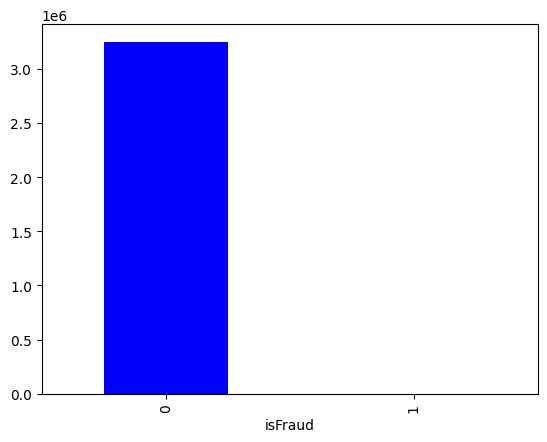

In [18]:
# visualizing the distribution of target feature

df['isFraud'].value_counts().plot(kind='bar', color=['blue', 'orange'])

In [19]:
# the dataset is highly impalanced
# seperating the data for analysis

legit= df[df.isFraud == 0]
fraud= df[df.isFraud == 1]

In [20]:
print(legit.shape)
print(fraud.shape)

(3248382, 14)
(3027, 14)


In [21]:
# statistical measures of the data

legit.amount.describe()

count    3.248382e+06
mean    -2.205969e-04
std      1.000179e+00
min     -7.677369e-01
25%     -6.898379e-01
50%     -5.276172e-01
75%      4.363543e-01
max      3.860923e+00
Name: amount, dtype: float64

In [22]:
fraud.amount.describe()

count    3027.000000
mean        0.236730
std         0.748416
min        -0.767737
25%        -0.423093
50%         0.109295
75%         0.784965
max         3.428620
Name: amount, dtype: float64

In [23]:
# comapre the values for the both transactions

df.groupby('isFraud').mean()

,step,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFlaggedFraud,type_CASH_OUT,type_DEBIT,type_PAYMENT,type_TRANSFER,balance_change_orig,balance_change_dest
isFraud,,,,,,,,,,,,,
0,245.629568,-0.000221,-0.002697,0.000379,0.000201,0.000238,0.0,0.421346,0.00693,0.510482,0.047066,0.003109,0.000204
1,361.157582,0.236730,2.893790,-0.407032,-0.215842,-0.255113,0.0,0.454906,0.00000,0.000000,0.545094,-3.336617,-0.219256


In [24]:
# under sampling
# built a sample dataset containing similar distribution of normal and fradulent transactions
# number of fraudulent transaction is 3027

legit_sample= legit.sample(n=3027)

In [25]:
#  concatenating two dataframes

new_dataset= pd.concat([legit_sample, fraud], axis=0)

In [26]:
# checking the new dataset

new_dataset.head()

,step,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud,type_CASH_OUT,type_DEBIT,type_PAYMENT,type_TRANSFER,balance_change_orig,balance_change_dest
3086305,235,-0.170555,-0.538030,-0.407032,1.047541,0.806711,0,0,True,False,False,False,0.412344,-0.096431
610123,34,2.319237,0.128681,-0.407032,-0.576470,0.313544,0,0,True,False,False,False,-0.315980,2.090714
2488910,204,-0.760836,1.361448,4.347622,-0.576470,-0.694528,0,0,False,False,True,False,0.386309,-0.621022
3706765,277,-0.748005,-0.538030,-0.407032,-0.576470,-0.694528,0,0,False,False,True,False,0.412344,-0.621022
6097839,522,-0.594827,-0.538030,-0.407032,-0.576470,-0.694528,0,0,False,False,True,False,0.412344,-0.621022


In [27]:
new_dataset.tail()

,step,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud,type_CASH_OUT,type_DEBIT,type_PAYMENT,type_TRANSFER,balance_change_orig,balance_change_dest
6362605,742,-0.263534,1.203388,-0.407032,-0.576470,-0.529877,1,0,True,False,False,False,-1.490001,-0.178108
6362608,742,1.615750,7.694074,-0.407032,-0.576470,-0.694528,1,0,False,False,False,True,-8.580503,-0.621022
6362609,742,1.615750,7.694074,-0.407032,-0.482168,0.159665,1,0,True,False,False,False,-8.580503,1.472740
6362610,742,-0.182676,1.482656,-0.407032,-0.576470,-0.694528,1,0,False,False,False,True,-1.795077,-0.621022
6362611,742,-0.182676,1.482656,-0.407032,0.458946,0.329334,1,0,True,False,False,False,-1.795077,-0.107079


In [28]:
# distribution of new dataset

new_dataset['isFraud'].value_counts()

isFraud
0    3027
1    3027
Name: count, dtype: int64

In [29]:
new_dataset.groupby('isFraud').mean()

,step,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFlaggedFraud,type_CASH_OUT,type_DEBIT,type_PAYMENT,type_TRANSFER,balance_change_orig,balance_change_dest
isFraud,,,,,,,,,,,,,
0,247.803436,-0.011875,-0.028732,-0.017111,-0.006734,-0.009008,0.0,0.418566,0.004295,0.518335,0.042616,0.024013,-0.009661
1,361.157582,0.236730,2.893790,-0.407032,-0.215842,-0.255113,0.0,0.454906,0.000000,0.000000,0.545094,-3.336617,-0.219256


In [30]:
# splitting the data into features and target

X = new_dataset.drop(['isFraud', 'isFlaggedFraud'], axis=1)
y = new_dataset['isFraud']
   
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [31]:
# model training

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score

#Train the Logistic Regression model
model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_train, y_train)

#Predictions
y_pred = model.predict(X_test)

#Evaluate the model
print(classification_report(y_test, y_pred))

#ROC-AUC Score
roc_auc = roc_auc_score(y_test, y_pred)
print(f"ROC-AUC Score: {roc_auc}")

              precision    recall  f1-score   support

           0       1.00      0.94      0.97       637
           1       0.94      0.99      0.97       574

    accuracy                           0.97      1211
   macro avg       0.97      0.97      0.97      1211
weighted avg       0.97      0.97      0.97      1211

ROC-AUC Score: 0.9683443733966381
